# Chromaticity and the mixture of extracted carbon and helium

The helium beam has a smaller horizontal emittance than carbon. At zero chromaticity it therefore takes longer to reach extraction under the common noise excitation. Positive horizontal chromaticity brings helium closer to the third-order resonance and reduces this delay.

We compare $Q'_x=0$ and $Q'_x=+1$ with the same initial particles, extraction-sextupole ramp and `xt.Exciter` waveform. The reference tune setting is $Q_x=1.665$, the peak extraction-sextupole strength is $3\,\mathrm{m}^{-2}$, and the RMS excitation rises from zero at 0.1 ms to $10^{-5}$ at 0.3 ms. Both runs last 5000 turns (about 2 ms).

The final figure compares the extracted fractions and the helium fraction of the extracted beam. The table quantifies the delay using the time to extract 10% of each initial beam.


In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xpart as xp
import xobjects as xo
import matplotlib.pyplot as plt

import numpy as np

In [3]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [4]:
PDG_ID_CARBON = p0_carbon.pdg_id[0]
PDG_ID_HELIUM = p0_helium.pdg_id[0]

In [5]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [6]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
# line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.configure_bend_model(num_multipole_kicks=5)
line.set_particle_ref('Carbon-12', q0=6, kinetic_energy0=200e6 * 12)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 0 # Debunched beam
line['frf'] = 1 / tw4d.t_rev0 # h=1

tw_carbon = line.twiss4d(zeta0=0)
tw_helium = line.twiss4d(mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca, zeta0=0)


Loading line from dict: 100%|##########| 86/86 [00:00<00:00, 9800.84it/s]


In [7]:
alpha_c = tw_carbon.momentum_compaction_factor
eta_c = tw_carbon.slip_factor
chi_he = charge_ratio_he_ca / mass_ratio_he_ca
delta_diff_expected = alpha_c / eta_c * (chi_he - 1)

In [8]:
opt = line.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.665, qy=1.72, tol=1e-4),
        xt.TargetSet(dx=0, at='mid.lss.0', tol=2e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=2e-3),
    ]
)
opt.step(20)
opt.target_status()

                                             
Matching: model call n. 1 penalty = 2.5041e-01              
Optimize - start penalty: 0.2504                         
Matching: model call n. 2 penalty = 2.5041e-01              
Matching: model call n. 3 penalty = 2.2885e-01              
Matching: model call n. 4 penalty = 5.9130e-01              
Matching: model call n. 5 penalty = 2.6301e-01              
Matching: model call n. 6 penalty = 2.5041e-01              
Matching: model call n. 7 penalty = 2.7742e-03              
Matching: model call n. 8 penalty = 2.7742e-03              
Matching: model call n. 9 penalty = 3.6660e-02              
Matching: model call n. 10 penalty = 5.8175e-01              
Matching: model call n. 11 penalty = 1.2327e-01              
Matching: model call n. 12 penalty = 2.7742e-03              
Matching: model call n. 13 penalty = 1.5671e-05              
Optimize - end penalty:  1.56713e-05                            
Matching: model call n. 14 penalty

In [9]:
# Calibrate the chromaticity knob with the extraction sextupoles at full strength.
env['kse'] = 3.
tw_chrom = line.twiss4d()

opt = line.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_x',
    knob_value_start=tw_chrom.dqx,
    knob_value_end=1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=1., dqy=tw_chrom.dqy, tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Matching: model call n. 1 penalty = 1.0227e+00              
Optimize - start penalty: 1.023                         
Matching: model call n. 2 penalty = 1.0227e+00              
Matching: model call n. 3 penalty = 1.0211e+00              
Matching: model call n. 4 penalty = 1.0222e+00              
Matching: model call n. 5 penalty = 1.0227e+00              
Matching: model call n. 6 penalty = 3.0244e-04              
Matching: model call n. 7 penalty = 3.0244e-04              
Matching: model call n. 8 penalty = 2.0255e-03              
Matching: model call n. 9 penalty = 1.9703e-03              
Matching: model call n. 10 penalty = 3.0244e-04              
Matching: model call n. 11 penalty = 1.1488e-06              
Optimize - end penalty:  1.14882e-06                            
Matching: model call n. 12 penalty = 1.1488e-06              
Target status:               
id state tag tol_met       residue   current_val    target_val desc

In [10]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.1, max_x=0.1, min_y=-0.1, max_y=0.1),

line.insert(['extr_septum', 'septum_aperture'], at=0)



In [11]:
line['kse'] # Full extraction-sextupole strength used above


3.0

In [12]:
line['chrom_x']=0
line.twiss4d().dqx

np.float64(-4.562643596278688e-06)

In [13]:
x_gen = np.linspace(0, 1e-2, 20)
p = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0)
p_he = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=delta_diff_expected,
                            mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca)

In [14]:
line.track(p, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec = line.record_last_track
line.track(p_he, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_he = line.record_last_track

In [15]:
x_septum = 3.5e-2

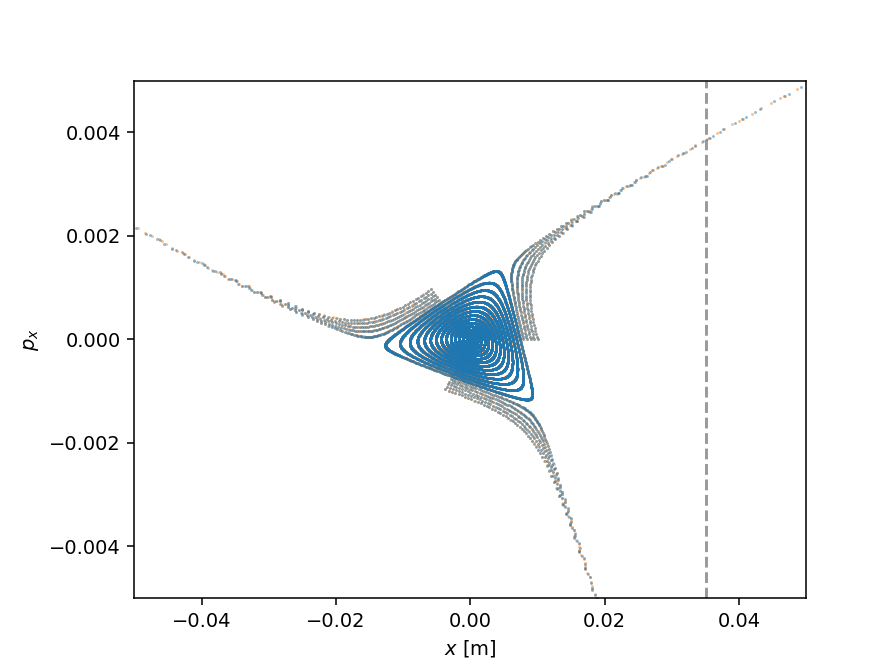

In [16]:
# Plot turn-by-turn data
plt.figure()
plt.plot(rec_he.x.T, rec_he.px.T, '.', markersize=1, color='C1', alpha=0.5)
plt.plot(rec.x.T, rec.px.T, '.', markersize=1, color='C0', alpha=0.5)
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)

### Build a matched beam distribution (carbon)

In [17]:
# Reproducible initial distributions for the chromaticity comparison.
np.random.seed(12345)

num_particles = 2000
beam_intensity = 1e10 # p+

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution (rms spread 5e-4)
delta = 5e-4 * np.random.normal(size=num_particles)

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
p0_carbon = line.build_particles(
    pdg_id=PDG_ID_CARBON,
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=1.e-6, nemitt_y=1e-6,
)



In [18]:
### Build a matched beam distribution (Helium)
num_particles = 2000
beam_intensity = 1e10 

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution (rms spread 5e-4)
delta = 5e-4 * np.random.normal(size=num_particles) + delta_diff_expected 

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
p0_helium = line.build_particles(
    pdg_id=PDG_ID_HELIUM,
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=0.05e-6, nemitt_y=1.e-6,
)

In [19]:
p0 = xt.Particles.merge([p0_carbon, p0_helium])

In [20]:
p0.pdg_id

array([1000060120, 1000060120, 1000060120, ..., 1000020040, 1000020040,
       1000020040], shape=(4000,))

### Define time-dependent behavior of extraction sextupoles

In [21]:
line.functions['fun_xsext'] = xt.FunctionPieceWiseLinear(x=[0, 0.1e-3, 0.5e-3], y=[0, 0, 1.])

line.ref['kse'] *= line.functions['fun_xsext'](line.vars['t_turn_s'])

# Inspect the expression
line.ref['kse']._expr

(3.0 * f['fun_xsext'](vars['t_turn_s']))

In [22]:
line['septum_aperture'].max_x = x_septum

In [23]:
ctx = xo.ContextCpu(omp_num_threads='auto')
line.build_tracker(_context=ctx)

In [24]:
# User-defined quantity to be logged
def measure_intensity_carbon(line, particles):
    mask_alive = particles.state > 0
    mask_carbon = particles.pdg_id == PDG_ID_CARBON
    intensity = np.sum(particles.weight[mask_carbon & mask_alive])
    return intensity
def measure_intensity_helium(line, particles):
    mask_alive = particles.state > 0
    mask_helium = particles.pdg_id == PDG_ID_HELIUM
    intensity = np.sum(particles.weight[mask_helium & mask_alive])
    return intensity

log = xt.Log('kse',              # vars to be logged
             intensity_carbon=measure_intensity_carbon,
             intensity_helium=measure_intensity_helium,
            ) # user-defined function to be logged

In [25]:
line.enable_time_dependent_vars = True

### Introduce transverse excitation to control the spill
We use `xt.Exciter` with one common Gaussian noise waveform sampled eight times per revolution. It selects the sample at each particle's arrival time, including its longitudinal offset. The amplitude controls the RMS horizontal kick for the reference species; `xt.Exciter` applies the species-dependent `chi` scaling.


In [26]:
num_turns = 5000
samples_per_turn = 8
rng = np.random.default_rng(12345)
# Allow ten turns of margin for arrival-time offsets at either end.
noise_samples = rng.normal(size=(num_turns + 20) * samples_per_turn)
noise_samples -= noise_samples.mean()
noise_samples /= noise_samples.std()

line.insert('spill_exc', xt.Exciter(
    samples=noise_samples,
    sampling_frequency=samples_per_turn / tw4d.t_rev0,
    frev=1 / tw4d.t_rev0,
    start_turn=-10,
    knl=[0.],
), at=0)


Use a gentle noise ramp during the sextupole ramp: the RMS kick rises from zero at 0.1 ms to $10^{-5}$ at 0.3 ms, then stays constant. Starting the excitation early avoids giving carbon a head start before helium is heated.


In [27]:
line.functions['fun_excit'] = xt.FunctionPieceWiseLinear(
    x=[0, 0.1e-3, 0.3e-3,    1e-3],
    y=[0, 0,       1e-5,     1e-5])

line.vars['ampl_excit'] = line.functions['fun_excit'](line.ref['t_turn_s'])
# Exciter uses the multipole convention: delta_px = -chi * knl[0] * sample.
line['spill_exc'].knl[0] = -env.ref['ampl_excit']


In [28]:
# The comparison below resets the simulation time and copies p0 for each run.
# The initial particles and the Exciter waveform are identical in both cases.


In [29]:
log = xt.Log(
    'kse', 't_turn_s', # vars to be logged
    'ampl_excit',
    intensity_carbon=measure_intensity_carbon, # user-defined functions to be logged
    intensity_helium=measure_intensity_helium
)       

In [30]:
chromaticities = [0., 1.]


In [31]:
log_results = {}
for chrom_x in chromaticities:
    line.enable_time_dependent_vars = False
    line['t_turn_s'] = 0
    line['chrom_x'] = chrom_x
    p = p0.copy()

    line.enable_time_dependent_vars = True
    line.track(p, num_turns=num_turns, with_progress=True, log=log)
    log_results[chrom_x] = {
        name: np.array(values).copy()
        for name, values in line.log_last_track.items()
    }


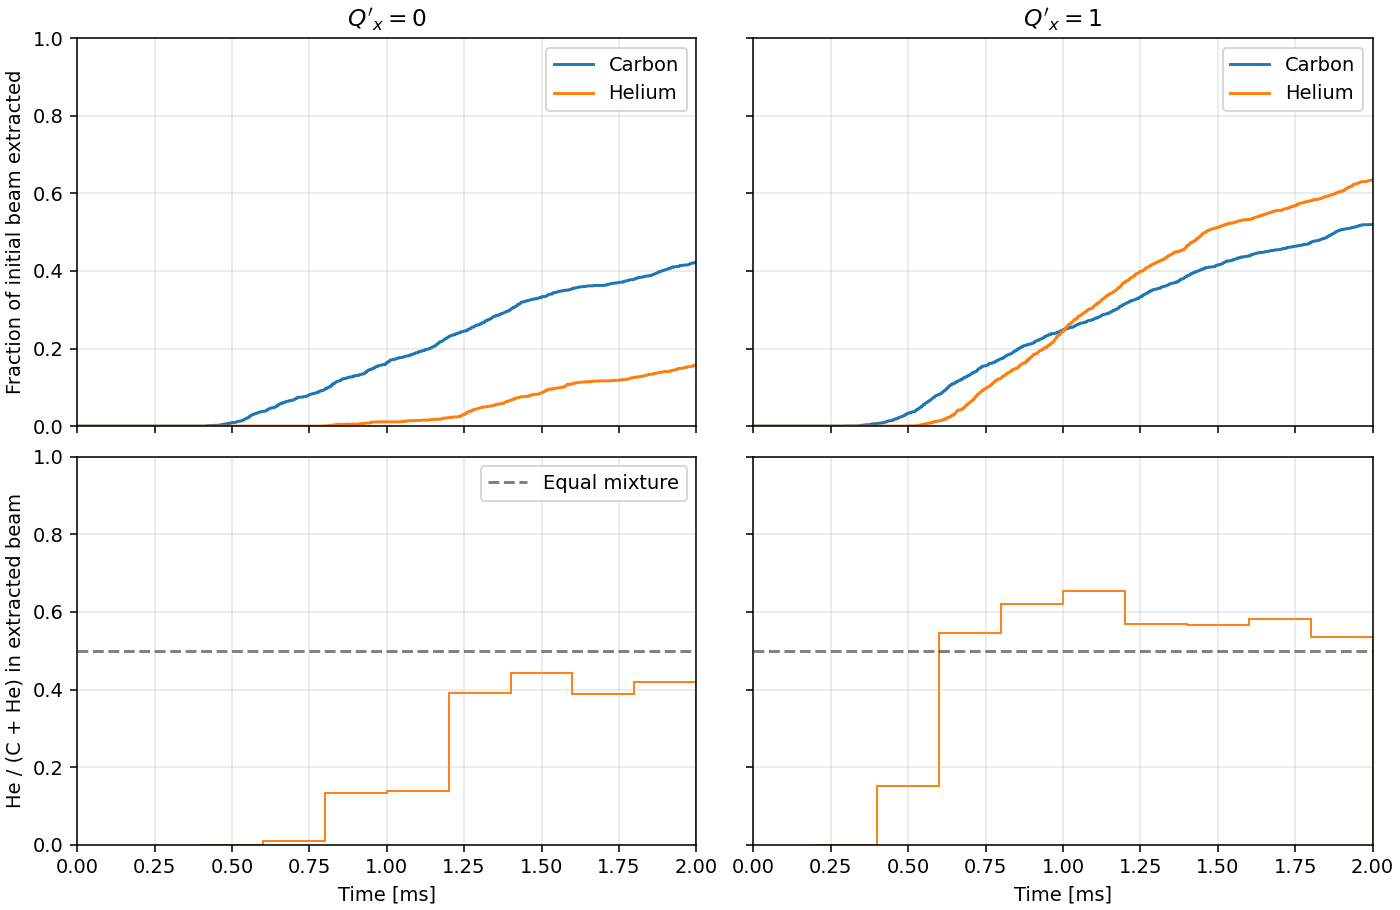

In [32]:
initial_intensity = {
    'carbon': measure_intensity_carbon(line, p0),
    'helium': measure_intensity_helium(line, p0),
}
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True,
                         sharey='row', constrained_layout=True)
bin_edges_ms = np.arange(0, 2.01, 0.2)

for column, chrom_x in enumerate(chromaticities):
    result = log_results[chrom_x]
    t_ms = result['t_turn_s'] * 1e3
    extracted_in_bin = {}
    for species, label in [('carbon', 'Carbon'), ('helium', 'Helium')]:
        intensity = result['intensity_' + species]
        axes[0, column].plot(
            t_ms, 1 - intensity / initial_intensity[species], label=label)
        extracted_in_bin[species] = -np.diff(
            np.interp(bin_edges_ms, t_ms, intensity))

    total = extracted_in_bin['carbon'] + extracted_in_bin['helium']
    helium_fraction = np.divide(
        extracted_in_bin['helium'], total,
        out=np.full_like(total, np.nan), where=total > 0)
    axes[1, column].stairs(helium_fraction, bin_edges_ms, color='C1')
    axes[1, column].axhline(0.5, color='k', linestyle='--', alpha=0.5,
                          label='Equal mixture')
    axes[0, column].set_title(rf"$Q'_x = {chrom_x:g}$")
    axes[0, column].legend()
    axes[1, column].set_xlabel('Time [ms]')
    for ax in axes[:, column]:
        ax.set_xlim(0, 2.)
        ax.set_ylim(0, 1.)
        ax.grid(alpha=0.3)

axes[0, 0].set_ylabel('Fraction of initial beam extracted')
axes[1, 0].set_ylabel('He / (C + He) in extracted beam')
axes[1, 0].legend()


### Quantify the helium delay
Compare the times at which 10% of each initial beam has been extracted. The lower panels above show the extracted mixture in 0.2 ms bins; empty bins are left blank. Equal initial intensities give a 50% helium fraction for an equal mixture.


In [33]:
print(" Q'x   t10 C [ms]   t10 He [ms]   He delay [ms]   Extracted C / He")
for chrom_x in chromaticities:
    result = log_results[chrom_x]
    t10 = {}
    final_fraction = {}
    for species in ['carbon', 'helium']:
        fraction = 1 - result['intensity_' + species] / initial_intensity[species]
        reached = np.flatnonzero(fraction >= 0.1)
        t10[species] = result['t_turn_s'][reached[0]] * 1e3 if len(reached) else np.nan
        final_fraction[species] = fraction[-1]
    delay = t10['helium'] - t10['carbon']
    print(f"{chrom_x:4.1f}   {t10['carbon']:10.3f}   {t10['helium']:11.3f}"
          f"   {delay:13.3f}   {final_fraction['carbon']:.1%} / {final_fraction['helium']:.1%}")


 Q'x   t10 C [ms]   t10 He [ms]   He delay [ms]   Extracted C / He
 0.0        0.812         1.564           0.753   43.0% / 16.2%
 1.0        0.630         0.756           0.126   52.4% / 63.9%


Helium starts with a smaller horizontal emittance, so at zero chromaticity it needs more excitation to reach extraction. Its larger magnetic rigidity lets positive chromaticity move its tune closer to the $Q_x=5/3$ resonance, reducing this delay. The same beam distributions, sextupole ramp and excitation waveform are used in both runs; only the chromaticity changes.
